In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pandas as pd
import muon as mu
import scanpy as sc
import scirpy as ir
np.random.seed(42)
import random
random.seed(42)

import sys
sys.path.append("/ihome/ylee/yiz133/Code/Data processing/functions")
import importlib
import mdata_utils

2025-11-03 13:22:24.856448: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-03 13:22:24.856812: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-03 13:22:24.910414: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-03 13:22:47.982536: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

In [2]:
# when functions changed
importlib.reload(mdata_utils)

<module 'mdata_utils' from '/ihome/ylee/yiz133/Code/Data processing/functions/mdata_utils.py'>

# GEX

In [29]:
data_path = "/ix1/ylee/Yifan_Zhang/Code_data/external/GSE178085 Bcl6KO_R Th17"
mdata = mu.read(data_path + "/GSE178085_Bcl6KO.h5mu")
mdata

MuData object with n_obs × n_vars = 511 × 31053
  2 modalities
    gex:	511 x 31053
      obs:	'sample', 'tissue', 'condition'
      var:	'gene_ids', 'feature_types'
    airr:	511 x 0
      obs:	'sample', 'tissue', 'condition'
      obsm:	'airr'

In [30]:
mdata['gex'].obs['tissue'] = mdata['gex'].obs['tissue'].replace({'CNS(men)': 'CNS', 'CNS(par)': 'CNS'})
mdata['gex'].obs['tissue']

AAACCCAGTCAGATTC-1    CNS
AAACGCTAGATTGATG-1    CNS
AAACGCTCAGTGAGCA-1    CNS
AAACGCTGTAACCCTA-1    CNS
AAAGGATCAGGTTCGC-1    CNS
                     ... 
TTTCATGGTACAGCGA-1    CNS
TTTCCTCAGAGGCGGA-1    CNS
TTTGATCTCCGGTTCT-1    CNS
TTTGATCTCCGTGCGA-1    CNS
TTTGGTTGTATTCCGA-1    CNS
Name: tissue, Length: 511, dtype: category
Categories (1, object): ['CNS']

In [31]:
mdata['gex'].obs['sample'] = mdata['gex'].obs['sample'].replace({'WM': 'Wt_men', 'WP': 'Wt_par', 'KM': 'KO_men', 'KP': 'KO_par'})
mdata['gex'].obs.rename(columns={'sample':'sample_id'})

,sample_id,tissue,condition
AAACCCAGTCAGATTC-1,Wt_men,CNS,wt
AAACGCTAGATTGATG-1,Wt_men,CNS,wt
AAACGCTCAGTGAGCA-1,Wt_men,CNS,wt
AAACGCTGTAACCCTA-1,Wt_men,CNS,wt
AAAGGATCAGGTTCGC-1,Wt_men,CNS,wt
...,...,...,...
TTTCATGGTACAGCGA-1,Wt_men,CNS,wt
TTTCCTCAGAGGCGGA-1,Wt_men,CNS,wt
TTTGATCTCCGGTTCT-1,Wt_men,CNS,wt
TTTGATCTCCGTGCGA-1,Wt_men,CNS,wt


In [32]:
%cd $data_path

/ix1/ylee/Yifan_Zhang/Code_data/external/GSE178085 Bcl6KO_R Th17


In [33]:
mdata.obs['GSE'] = 'GSE178085'
mdata.obs['GSM'] = mdata['gex'].obs['sample']
mdata.obs['tissue'] = mdata['gex'].obs['tissue']

In [34]:
## data specific features
mdata.obs['condition'] = 'EAE'
mdata['gex'].obs['sample_id'] = 'mixed'

# mdata['gex'].obs['cell_type'] = 'CD4'
# mdata['gex'].obs['state'] = 'Trm'
    

In [35]:
mdata = mdata_utils.pp_EAE(mdata, celltype_score = 0.4, cellstate_score = 0.4, topN_variable = None)

In [36]:
print(mdata['gex'].obs['cell_type'].value_counts())
print(mdata['gex'].obs['state'].value_counts())

cell_type
CD4     105
CD8      72
Th17     61
Treg     42
Name: count, dtype: int64
state
Mem_Naive     192
Activation     71
Exhaust        36
IFN_stim       35
Name: count, dtype: int64


# TCR

In [37]:
# mdata = mdata_ori.copy()
mdata['airr'].obs['sample_id'] = mdata.obs['sample_id']

ir.pp.index_chains(mdata)
ir.tl.chain_qc(mdata)

ir.pp.ir_dist(mdata)
ir.tl.define_clonotypes(mdata, receptor_arms="all", dual_ir="primary_only", within_group = 'sample_id')

meta_airr = ir.get.airr(mdata['airr'], ["cdr3_aa", "v_call", "j_call"] ,  ('VJ_1', 'VDJ_1'))

df2_filtered = meta_airr.loc[:, ~meta_airr.columns.isin(mdata.obs.columns)]
mdata.obs = mdata.obs.join(df2_filtered)
mdata.update()

# mdata.obs = mdata.obs.reindex(mdata.mod['gex'].obs.index)
ir.tl.clonal_expansion(mdata)


In [38]:
mdata

MuData object with n_obs × n_vars = 511 × 7228
  obs:	'GSE', 'GSM', 'tissue', 'condition', 'state', 'cell_type', 'sample_id', 'VJ_1_cdr3_aa', 'VJ_1_v_call', 'VJ_1_j_call', 'VDJ_1_cdr3_aa', 'VDJ_1_v_call', 'VDJ_1_j_call'
  2 modalities
    gex:	511 x 7228
      obs:	'sample', 'tissue', 'condition', 'sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts', 'CD4score', 'CD8score', 'Tregscore', 'Th17score', 'cell_type', 'IFN_stimscore', 'Activationscore', 'Exhaustscore', 'Mem_Naivescore', 'state'
      var:	'gene_ids', 'feature_types', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
      uns:	'log1p'
    airr:	511 x 0
      obs:	'sample', 'tissue', 'condition', 'sample_id', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id', 'clone_id_size', 'clonal_expansion'
      uns:	'chain_indices', 'ir_dist_nt_identity', 'clone_id'
      obsm:	'airr', 'chain_indices'

In [39]:
count = (mdata['airr'].obs['clone_id_size'] == 1).sum()
print(count)

0


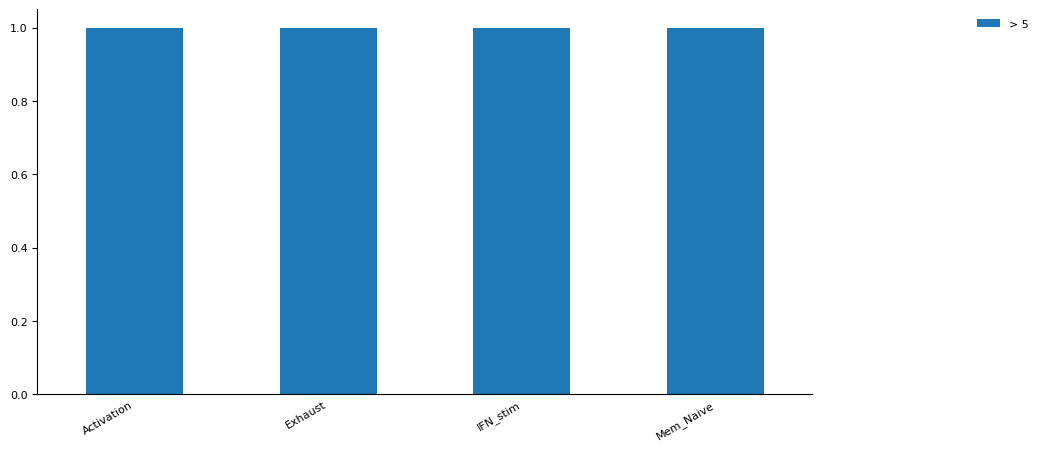

In [40]:
fig, ax = plt.subplots(figsize=(10, 5))
_ = ir.pl.clonal_expansion(
    mdata, 
    target_col="clone_id",
    groupby="state",  # Use the new combined column
    breakpoints=(1, 2, 5), 
    ax = ax
    #normalize=False
)

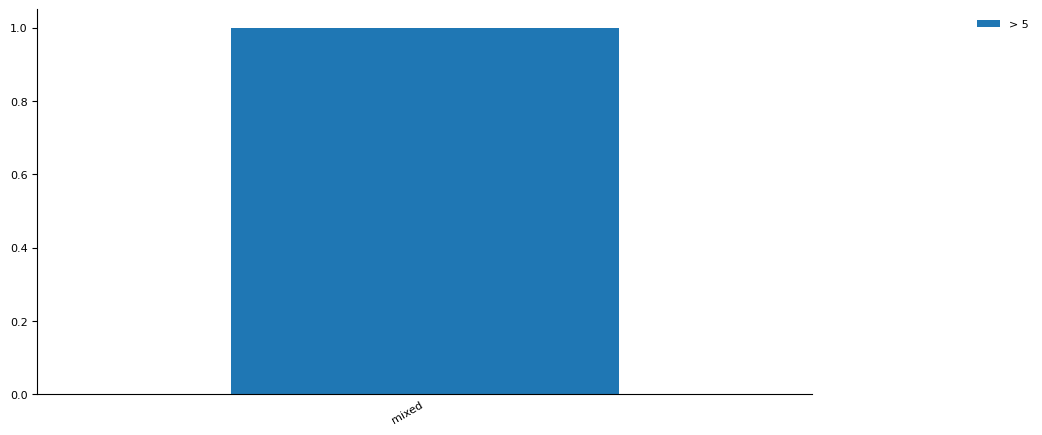

In [41]:
fig, ax = plt.subplots(figsize=(10, 5))
_ = ir.pl.clonal_expansion(
    mdata, 
    target_col="clone_id",
    groupby= 'sample_id',  # Use the new combined column
    breakpoints=(1, 2, 5), 
    ax = ax
    #normalize=False
)

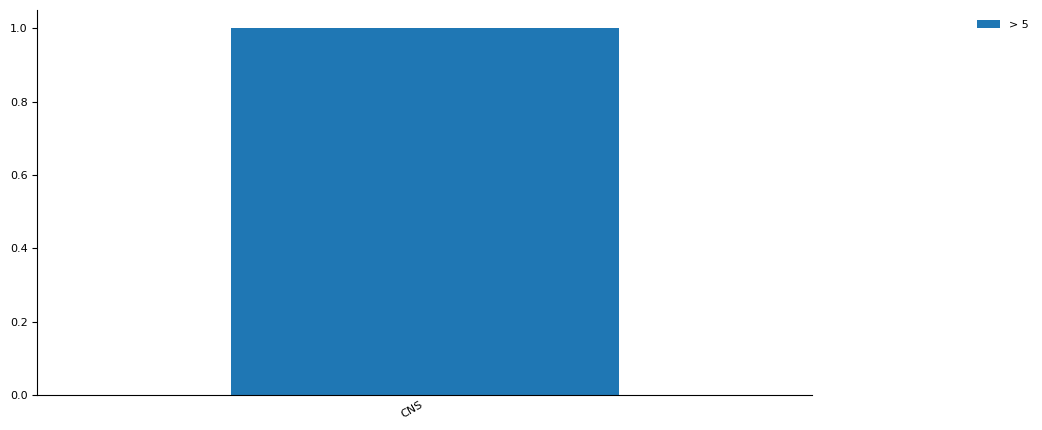

In [42]:
fig, ax = plt.subplots(figsize=(10, 5))
_ = ir.pl.clonal_expansion(
    mdata, 
    target_col="clone_id",
    groupby= 'tissue',  # Use the new combined column
    breakpoints=(1, 2, 5), 
    ax = ax
    #normalize=False
)

In [43]:
# mdata.write('yz_processed_allGenes_annotateByRef.h5mu')
mdata.write('yz_processed_allGenes_annotateByScore.h5mu')

In [44]:
aa

NameError: name 'aa' is not defined

# cluster and plot

In [ ]:
sc.pp.pca(mdata["gex"], svd_solver="arpack", n_comps=50)
sc.pp.neighbors(mdata["gex"], n_neighbors = 50)
sc.tl.umap(mdata["gex"], min_dist=0.5, spread=1.0)

In [ ]:
sc.pl.umap(mdata["gex"], color=['state', 'tissue', 'cell_type'], ncols=2,)

In [ ]:
# markers_in = []
# for i in ['Ccr6', 'Il22', 'Il17', 'Il17a'] + genes:
#     if i in mdata["gex"].var_names:
#         markers_in.append(i) 
# mu.pl.embedding(mdata["gex"], basis="umap", color= markers_in,  wspace = 0.1, ncols=2, vmin=0)